# Atelier Préparation de Données Tabulaires 
Contexte 
Une entreprise exploite plusieurs bâtiments intelligents équipés de capteurs IoT. Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la qualité de l'air, la consommation énergétique, le nombre de personnes présentes, le type de bâtiment, le mode de fonctionnement et l'état du système de climatisation. Les données collectées sont destinées à alimenter ultérieurement un modèle de Machine Learning capable de prédire la consommation énergétique ou de détecter les situations anormales. Cependant, les données brutes présentent volontairement différents problèmes : valeurs manquantes, doublons, valeurs aberrantes, types incorrects, valeurs incohérentes, variables catégorielles, catégories rares, déséquilibre des classes et échelles différentes entre variables. L'objectif de l'atelier est donc de transformer le fichier brut en un jeu de données propre et prêt pour le Machine Learning. Objectifs pédagogiques À la fin de l'atelier, l'apprenant doit être capable de :
 1) explorer un jeu de données tabulaire ; 
 2) identifier les différents types de variables ; 
 3) détecter les problèmes de qualité ; 
 4) analyser les valeurs manquantes ; 
 5) détecter et traiter les doublons ; 
 6) identifier les valeurs aberrantes ; 
 7) détecter les incohérences ; 
 8) analyser le déséquilibre des classes ; 
 9) choisir une stratégie d'encodage adaptée ; 
 10) appliquer différents encodages catégoriels ; 
 11) normaliser et standardiser les variables numériques ; 
 12) éviter la fuite de données ; 
 13) construire un pipeline de preprocessing avec Scikit-learn ; 
 14) produire un dataset final exploitable par un algorithme de Machine Learning. 

# Partie 1 – Explorer les données 


## 1) Charger les données CSV ; 

In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("../data/smart_building_raw.csv")


## 2) Afficher les premières lignes du dataset ; 

In [4]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


## 3) Afficher les dernières lignes du dataset ; 


In [5]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


## 4) Combien d'observations contient le dataset ? 

In [6]:
print(len(df))
print(df.shape[0])

507
507


## 5) Combien de variables possède le dataset ? 


In [7]:
print(len(df.columns))
print(df.shape[1])


14
14


## 6) Identifier les variables numériques ; 

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_mesure           507 non-null    int64  
 1   date                507 non-null    str    
 2   batiment            507 non-null    str    
 3   type_batiment       503 non-null    str    
 4   zone                507 non-null    str    
 5   temperature         495 non-null    float64
 6   humidite            496 non-null    float64
 7   co2                 500 non-null    float64
 8   occupation          501 non-null    float64
 9   consommation_kwh    502 non-null    float64
 10  mode_climatisation  502 non-null    str    
 11  etat_systeme        507 non-null    str    
 12  jour_semaine        502 non-null    str    
 13  alerte              507 non-null    str    
dtypes: float64(5), int64(1), str(8)
memory usage: 55.6 KB


In [9]:
variables_numeriques = df.select_dtypes(include=[np.float64]).columns.tolist()

print(variables_numeriques)

['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


## 7) Identifier les variables catégorielles

In [10]:
variables_categorielles = df.select_dtypes(include="str").columns.tolist()
variables_categorielles.remove("date")
print(variables_categorielles)

['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


## 8) Identifier les dates 

In [11]:
dates = ["date"]
dates

['date']

## 9) Identifier les identifiants 

In [12]:
identifiants = df.select_dtypes(include=[np.int64]).columns.tolist()
identifiants

['id_mesure']

## 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles. 

In [13]:
df[variables_numeriques].describe().round(2)

,temperature,humidite,co2,occupation,consommation_kwh
count,495.00,496.00,500.00,501.00,502.00
mean,24.15,57.86,844.15,44.85,169.07
std,7.42,16.03,582.18,24.95,53.16
min,-30.00,-12.00,89.00,-20.00,-100.00
25%,21.60,49.28,623.75,27.00,136.88
50%,24.00,57.55,787.50,46.00,169.80
75%,26.00,65.75,952.00,61.00,202.98
max,96.00,160.00,6000.00,116.00,336.20


## 11) Variables potentiellement problématiques

En comparant les valeurs min/max de `.describe()` aux limites physiquement possibles pour
chaque variable, plusieurs incohérences apparaissent :

- **temperature** : min = -30°C, max = 96°C → des valeurs impossibles pour un bâtiment
  climatisé (plage réaliste attendue : environ 15°C à 35°C).
- **humidite** : min = -12%, max = 160% → un taux d'humidité est un pourcentage, il ne
  peut donc pas être négatif ni dépasser 100%.
- **occupation** : min = -20 → un nombre de personnes ne peut pas être négatif.
- **consommation_kwh** : min = -100 → une consommation d'énergie ne peut pas être négative.
- **co2** : max = 6000 ppm → valeur élevée mais pas physiquement impossible ; à surveiller
  plutôt qu'à corriger d'office.




## 12) Pour les données incohérentes : 

### a) rechercher des valeurs telles que humidité < 0 ; 

In [14]:
print("a) humidité < 0   :", (df["humidite"] < 0).sum(), "lignes")


a) humidité < 0   : 3 lignes


In [15]:
# acceder aux valeurs manquantes de la colonne humidité loc[ligne, colonne]

df.loc[df["humidite"] < 0, "humidite"]

281    -5.0
335    -8.0
366   -12.0
Name: humidite, dtype: float64

### b) rechercher des valeurs telles que humidité > 100 ; 

In [16]:
print("b) Valeurs humidité > 100 :")
print((df["humidite"] > 100).sum(), "lignes")
print(df.loc[df["humidite"] > 100, "humidite"].tolist())

b) Valeurs humidité > 100 :
7 lignes
[108.0, 145.0, 160.0, 125.0, 140.0, 132.0, 110.0]


### c) rechercher des valeurs telles que température extrêmement élevée ; 

In [17]:
print("c) Valeurs température extrême :")
print(((df["temperature"] > 45) ).sum(), "lignes")
print(df.loc[(df["temperature"] > 45) , "temperature"].tolist())

c) Valeurs température extrême :
4 lignes
[72.5, 96.0, 88.0, 95.2]


### d) rechercher des valeurs telles que occupation négative

In [18]:
print("d) Valeurs occupation négative :")
print((df["occupation"] < 0).sum(), "lignes")
print(df.loc[df["occupation"] < 0, "occupation"].tolist())

d) Valeurs occupation négative :
5 lignes
[-5.0, -8.0, -12.0, -2.0, -20.0]


### e) rechercher des valeurs telles que consommation négative ; 

In [19]:
print("e) Valeurs consommation négative :")
print((df["consommation_kwh"] < 0).sum(), "lignes")
print(df.loc[df["consommation_kwh"] < 0, "consommation_kwh"].tolist())

e) Valeurs consommation négative :
4 lignes
[-15.0, -50.0, -20.0, -100.0]


### f) Si une valeur est manifestement erronée et qu’on ne peut pas retrouver sa vraie valeur, la transformer en valeur manquante 



In [20]:
df.loc[df["humidite"] < 0, "humidite"] = np.nan
df.loc[df["humidite"] > 100, "humidite"] = np.nan
df.loc[(df["temperature"] > 45), "temperature"] = np.nan
df.loc[df["occupation"] < 0, "occupation"] = np.nan
df.loc[df["consommation_kwh"] < 0, "consommation_kwh"] = np.nan

### verification

In [21]:
print(df.loc[df["consommation_kwh"] < 0, "consommation_kwh"].tolist())

[]


### g) rechercher des valeurs telles que catégories mal orthographiées. 

In [22]:
# lecture des valeurs uniques pour les variables catégorielles

for col in variables_categorielles:
    print(f"--- {col} ---")
    print(df[col].unique())
    print()

--- batiment ---
<StringArray>
['B8', 'B7', 'B5', 'B6', 'B3', 'B4', 'B2', 'B1']
Length: 8, dtype: str

--- type_batiment ---
<StringArray>
[         'Entrepôt',            'Bureau', 'Centre commercial',
        'Université',           'Hôpital',             'École',
             'ÉCOLE',             'ecole',            'BUREAU',
                 nan,             'Bureu',            'bureau',
       ' UNIVERSITÉ',          'hôpital ', 'centre commercial',
          ' Bureau ',          'entrepot']
Length: 17, dtype: str

--- zone ---
<StringArray>
['A', 'D', 'B', 'C']
Length: 4, dtype: str

--- mode_climatisation ---
<StringArray>
['Eco', 'Normal', 'Boost', nan, 'normal', 'BOOST', 'normale', 'Normal ']
Length: 8, dtype: str

--- etat_systeme ---
<StringArray>
['Normal', 'Alerte', 'Panne']
Length: 3, dtype: str

--- jour_semaine ---
<StringArray>
['Jeudi', 'Lundi', 'Dimanche', 'Vendredi', 'Mercredi', 'Mardi', 'Samedi', nan]
Length: 8, dtype: str

--- alerte ---
<StringArray>
['Non', 'Oui

### 

**type_batiment** contient plusieurs variantes qui désignent la même catégorie :
- Variations de casse : "BUREAU", "Bureau", "bureau"
- Espaces parasites : " Bureau ", "hôpital "
- Accents manquants : "ecole" (école), "entrepot" (entrepôt)
- Faute de frappe : "Bureu" (bureau)

**mode_climatisation** présente le même type de problème :
- Casse : "BOOST", "Boost"
- Espace parasite : "Normal "
- Variante orthographique : "normale" (normal)

### h) normaliser les catégories textuelles en supprimant les espaces puis en uniformisant la casse

In [23]:
#Pour chaque valeur texte de cette colonne, enlève les espaces autour, 
# puis mets tout en minuscules, et remplace la colonne d'origine par le résultat.

for col in variables_categorielles:
    df[col] = df[col].str.strip().str.lower()

In [24]:
# Correction des valeurs pour les variables catégorielles faute de frappe ou d'orthographe

corrections_type_batiment = {
    "bureu": "bureau",
    "ecole": "école",
    "entrepot": "entrepôt",
}
df["type_batiment"] = df["type_batiment"].replace(corrections_type_batiment)

corrections_climatisation = {
    "normale": "normal",
}
df["mode_climatisation"] = df["mode_climatisation"].replace(corrections_climatisation)

In [25]:
# verification des corrections
for col in variables_categorielles:
    print(f"--- {col} ---")
    print(col, "→", sorted(df[col].dropna().unique()))  
    print()
    

--- batiment ---
batiment → ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']

--- type_batiment ---
type_batiment → ['bureau', 'centre commercial', 'entrepôt', 'hôpital', 'université', 'école']

--- zone ---
zone → ['a', 'b', 'c', 'd']

--- mode_climatisation ---
mode_climatisation → ['boost', 'eco', 'normal']

--- etat_systeme ---
etat_systeme → ['alerte', 'normal', 'panne']

--- jour_semaine ---
jour_semaine → ['dimanche', 'jeudi', 'lundi', 'mardi', 'mercredi', 'samedi', 'vendredi']

--- alerte ---
alerte → ['non', 'oui']



## 13) Pour les valeurs manquantes : 

### a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne 

In [26]:
manquants = df.isna().sum()
manquants 


id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           16
humidite              21
co2                    7
occupation            11
consommation_kwh       9
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

In [27]:
len(df)

507

In [28]:
pourcentage = (df.isna().sum() / len(df) * 100).round(2)
pourcentage



id_mesure             0.00
date                  0.00
batiment              0.00
type_batiment         0.79
zone                  0.00
temperature           3.16
humidite              4.14
co2                   1.38
occupation            2.17
consommation_kwh      1.78
mode_climatisation    0.99
etat_systeme          0.00
jour_semaine          0.99
alerte                0.00
dtype: float64

In [29]:
tableau_manquants = pd.DataFrame({"nb_manquants": manquants, "pct_manquants": pourcentage})
tableau_manquants = tableau_manquants[tableau_manquants["nb_manquants"] > 0].sort_values("nb_manquants", ascending=False)
print(tableau_manquants)

                    nb_manquants  pct_manquants
humidite                      21           4.14
temperature                   16           3.16
occupation                    11           2.17
consommation_kwh               9           1.78
co2                            7           1.38
mode_climatisation             5           0.99
jour_semaine                   5           0.99
type_batiment                  4           0.79


### b) Quelle variable possède le plus de valeurs manquantes ? 

humidite, avec 21 valeurs manquantes (4,14% du dataset).

### c) Quelle stratégie utiliser pour les valeurs manquantes ?

Chez nous, toutes les colonnes ont un taux de valeurs manquantes faible (< 5%). Dans ce cas,
plusieurs stratégies sont défendables :
- Imputation par la médiane pour les variables numériques (robuste aux valeurs extrêmes)
- Imputation par le mode pour les variables catégorielles


### d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ? 

Techniquement oui, mais ce n'est pas recommandé ici : en cumulant les colonnes concernées,
supprimer une ligne dès qu'UNE colonne est manquante ferait perdre bien plus que 4% des lignes
au total (les valeurs manquantes ne sont pas forcément sur les mêmes lignes d'une colonne à
l'autre). Sur seulement 507 observations, on ne peut pas se permettre de perdre autant de
données pour un projet de Machine Learning.

### e) Quand utiliser la moyenne ?

Quand la distribution de la variable est à peu près symétrique (pas d'asymétrie forte, pas de
valeurs extrêmes qui tirent la moyenne vers le haut ou le bas).

### f) Quand préférer la médiane ?

Quand la distribution est asymétrique ou contient des valeurs extrêmes (outliers) : la médiane
n'est pas influencée par les valeurs très hautes ou très basses, contrairement à la moyenne.
Dans notre cas, temperature/humidite/consommation contenaient des valeurs aberrantes avant
nettoyage (12-a à e) — même après les avoir mises à NaN, la médiane reste le choix le plus sûr.


### g) Comment traiter une variable catégorielle manquante ?

Par imputation avec le mode (la valeur la plus fréquente de la colonne), car la moyenne/médiane
n'ont pas de sens sur du texte.

### 

L'approche standard consiste à imputer par le **mode** (la valeur la plus fréquente), car la
moyenne/médiane n'ont pas de sens sur du texte.

**Limite constatée sur nos données** : imputer aveuglément par le mode global ignore le contexte
des autres colonnes de la ligne. En vérifiant les 5 lignes où `mode_climatisation` est manquant,
on observe que leur `consommation_kwh` ne correspond pas toujours au mode "normal" (le mode
global) : par exemple la ligne id_mesure=1008 a une consommation de 236 kWh, largement plus
proche de la moyenne du mode "boost" (203 kWh) que de "normal" (165 kWh). Imputer "normal"
créerait donc une contradiction interne sur cette ligne, qui viendrait bruiter l'étude de la
relation entre mode de climatisation et consommation énergétique .

**Stratégie retenue** : imputation par le mode **conditionnel**, basé sur la variable numérique
la plus liée (`consommation_kwh`), plutôt qu'un mode global appliqué sans distinction.

## 14) pour les doublons

### a) Identifier les

In [30]:
# toutes les lignes dupliquées sont affichées, pas seulement la première ou la dernière
doublons = df[df.duplicated(keep=False)]
print("Nombre de lignes concernées par un doublon :", len(doublons))


Nombre de lignes concernées par un doublon : 14


### b) Afficher les 


In [31]:
doublons.sort_values("id_mesure")

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
117,1026,2025-01-07 06:00:00,b6,bureau,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
455,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


### c) sont-ils réellement identiques ? 

In [32]:
# Comparer : doublons au sens strict (toutes colonnes) vs doublons juste sur id_mesure
doublons_id_seul = df[df.duplicated(subset="id_mesure", keep=False)]
doublons_complets = df[df.duplicated(keep=False)]

print("Lignes avec id_mesure dupliqué :", len(doublons_id_seul))
print("Lignes identiques sur TOUTES les colonnes :", len(doublons_complets))

Lignes avec id_mesure dupliqué : 14
Lignes identiques sur TOUTES les colonnes : 14


### 

Oui. Les 7 paires détectées via id_mesure sont aussi des doublons parfaits sur l'ensemble des
14 colonnes (même date, même bâtiment, mêmes mesures). Il ne s'agit pas de deux mesures
différentes partageant accidentellement un même identifiant, mais bien de la même ligne
insérée deux fois dans le fichier

### d) supprimer les doublons réellement identifiés. 

In [33]:
df = df.drop_duplicates(keep="first")

### e) Vérifier la suppression 

In [34]:
print("Nombre de lignes après suppression :", len(df))
print("Doublons restants :", df.duplicated().sum())

Nombre de lignes après suppression : 500
Doublons restants : 0


## 15) Pour la température, l’humidité, le CO₂ et la consommation, identifier visuellement : 

### a) Les distributions (symétrique ou non) 

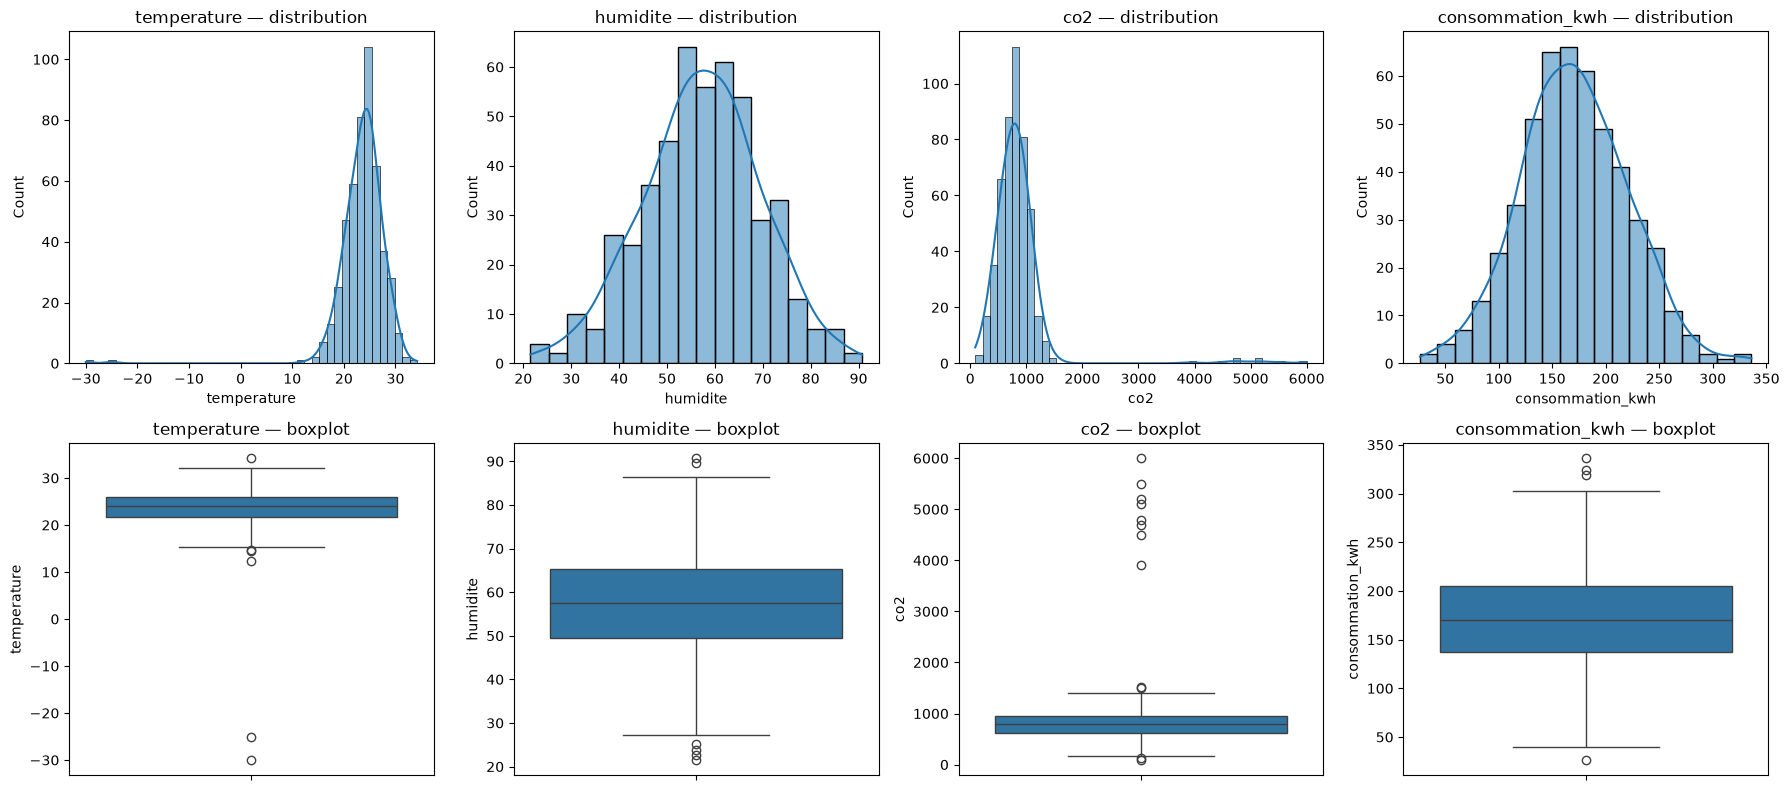

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

colonnes = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(colonnes):
    # Ligne du haut : histogrammes -> pour la symétrie (15-a)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"{col} — distribution")

    # Ligne du bas : boxplots -> pour dispersion, extrêmes, aberrantes (15-b, c, d)
    sns.boxplot(y=df[col], ax=axes[1, i])
    axes[1, i].set_title(f"{col} — boxplot")

plt.tight_layout()
plt.show()


temperature : semble quasi symétrique, avec une légère traîne visible vers les valeurs basses
humidite : semble symétrique
co2 : semble  nettement asymétrique à droite (étalement vers les valeurs élevées)
consommation_kwh : semble symétrique

### b) La dispersion 

- temperature : faible
- humidite : modérée
- co2 : faible pour la majorité des valeurs, malgré une plage totale très étendue
- consommation_kwh : modérée à large

### c) Les valeurs extrêmes 

- temperature : ~14°C (bas) à ~30°C (haut)
- humidite : ~30% (bas) à ~90% (haut)
- co2 : ~150 (bas) à ~1400 (haut)
- consommation_kwh : ~50 (bas) à ~300 (haut)

### d) les valeurs potentiellement aberrantes 
- temperature : points en dessous de -20/-30
- humidite : points en dessous de 20-25
- co2 : nombreux points au-dessus de 1500, jusqu'à 6000
- consommation_kwh : un point au-dessus de ~300-350

## 16) Quelle stratégie utiliser pour les valeurs aberrantes ? 


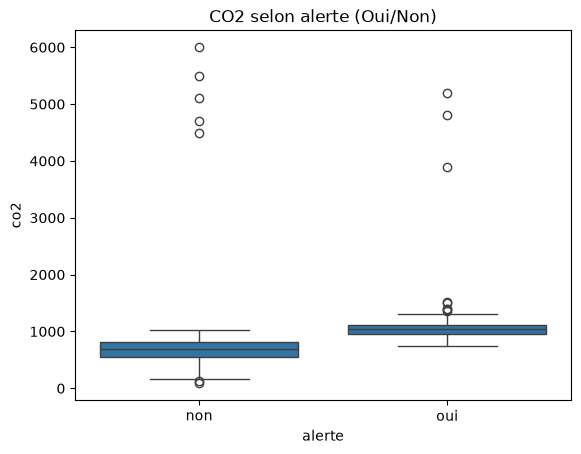

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="alerte", y="co2", data=df)
plt.title("CO2 selon alerte (Oui/Non)")
plt.show()

**Constat visuel (boxplot co2 selon alerte)** : la boîte de CO2 est nettement plus haute pour
les enregistrements avec alerte="Oui" (médiane ≈ 1035) que pour alerte="Non" (médiane ≈ 687),
avec des intervalles interquartiles qui ne se chevauchent presque pas. Les valeurs de CO2
statistiquement aberrantes (au-delà de 1444, borne IQR) apparaissent donc plus fréquemment
associées à une vraie situation d'alerte que la moyenne du dataset ne le laisserait attendre.

**Décision : on conserve les valeurs aberrantes de co2 telles quelles**, sans les supprimer
ni les écrêter (capping), pour la raison suivante : l'objectif final du projet est notamment
de détecter les situations anormales (variable cible `alerte`). Si ces CO2 élevés sont
statistiquement rares mais réellement associés aux alertes, les supprimer ou les ramener à
une valeur "normale" reviendrait à effacer précisément le signal que le modèle doit apprendre
à reconnaître. Une valeur aberrante n'est pertinente à corriger que lorsqu'elle est une erreur
(cas déjà traité en question 12) — ici, rien n'indique que ces CO2 élevés soient des erreurs
de mesure plutôt que de vraies conditions associées à une alerte.

**Nuance pour les autres variables (temperature, humidite, consommation_kwh)** : leurs
valeurs aberrantes sont peu nombreuses (4 à 6) et ne montrent pas la même association avec
`alerte` — on les conserve également telles quelles, faute d'élément justifiant une
correction, mais sans le même argument fort que pour co2.

## 17) Afficher la fréquence des :

### a) bâtiments ;

In [45]:
df["batiment"].value_counts()

batiment
b1    92
b5    65
b7    64
b2    60
b4    58
b3    57
b8    53
b6    51
Name: count, dtype: int64

### b) types de bâtiments ;

In [46]:
df["type_batiment"].value_counts()

type_batiment
bureau               211
centre commercial     65
école                 60
hôpital               58
entrepôt              53
université            49
Name: count, dtype: int64

### c) modes de climatisation ;

In [47]:
df["mode_climatisation"].value_counts()

mode_climatisation
normal    268
eco       130
boost      97
Name: count, dtype: int64

### d) états du système ;

In [48]:
df["etat_systeme"].value_counts()

etat_systeme
normal    436
alerte     52
panne      12
Name: count, dtype: int64

### e) classes alerte.

In [49]:
df["alerte"].value_counts()

alerte
non    356
oui    144
Name: count, dtype: int64

## 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

Le terme "classe" s'applique à la variable cible d'une classification, ici `alerte`.

**Résultat** : 71,2% "Non" (356 lignes) / 28,8% "Oui" (144 lignes).

**Interprétation** : déséquilibre modéré (ratio ~2,5:1). Ce n'est pas un déséquilibre extrême
(comme 95%/5%), mais suffisant pour en tenir compte lors du découpage Train/Test (Partie 3),
en utilisant `stratify=y` afin de conserver cette même proportion 71/29 dans les ensembles
d'entraînement et de test.

**Sur les variables explicatives** : certaines catégories des variables de X sont elles aussi
peu représentées (ex: etat_systeme="Panne" à 2,6%, 12 lignes). Ce n'est pas un déséquilibre
de classes au sens strict (ce ne sont pas des cibles), mais un point de vigilance similaire :
avec si peu d'exemples, le modèle aura peu de matière pour apprendre un lien fiable avec
cette catégorie.

## 19) Pour la corrélation sur les variables numériques :

### a) visualiser avec seaborn, la matrice de corrélation.

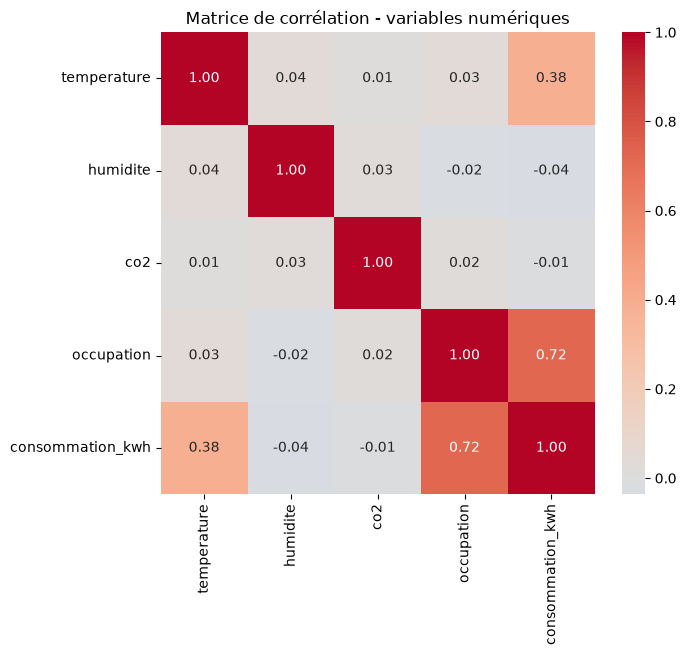

In [50]:
numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]

matrice_corr = df[numeriques].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(matrice_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation - variables numériques")
plt.show()

### b) identifier les corrélations positives, négatives et les variables faiblement corrélées.



**Corrélation positive notable** :
- `occupation` ↔ `consommation_kwh` : 0.65 → nettement la plus forte relation du dataset.
  Logique : plus il y a de personnes dans le bâtiment, plus la consommation énergétique
  augmente (éclairage, appareils, climatisation sollicitée).
- `temperature` ↔ `consommation_kwh` : 0.29 → corrélation positive modérée. Cohérent avec
  l'usage de la climatisation qui consomme davantage quand il fait plus chaud.

**Corrélations faibles ou quasi nulles** (à considérer comme non significatives) :
- `co2` avec toutes les autres variables : entre -0.04 et 0.03 → aucun lien linéaire direct,
  confirme ce qu'on avait déjà observé avec `consommation_kwh` (-0.01) à la question 16.
- `humidite` avec toutes les autres : entre -0.06 et 0.09 → également très faible.
- `temperature` ↔ `humidite` : 0.09 → quasi nul.

**Aucune corrélation négative forte** dans ce dataset — les seules valeurs négatives
(`humidite`/`consommation_kwh` à -0.06, `co2`/`consommation_kwh` à -0.01, etc.) sont
trop proches de 0 pour être interprétées comme un vrai lien inverse.

**Conclusion pratique** : pour prédire `consommation_kwh`, les variables les plus utiles
sont `occupation` (forte) et `temperature` (modérée). `co2` et `humidite` n'apportent
quasiment aucune information linéaire pour cette tâche précise.

# Partie 2 – Séparation X / y

## 1) Définir la variable "alerte" comme la cible y

In [56]:
y = df["alerte"]


## 2) Trouver des variables explicatives X pertinentes

In [55]:
colonnes_a_exclure = ["id_mesure", "date", "alerte"]
X = df.drop(columns=colonnes_a_exclure)


## 3) Afficher les cinq premières lignes de X ainsi que de y

In [57]:
print(X.head())
print()
print(y.head())

  batiment      type_batiment zone  temperature  humidite     co2  occupation  \
0       b8           entrepôt    a         23.0      40.0   851.0        26.0   
1       b7             bureau    d         28.0      69.0   538.0         0.0   
2       b5  centre commercial    b         19.5      52.3  1198.0        64.0   
3       b6         université    d         20.0      58.4  1014.0        30.0   
4       b7             bureau    d         26.8      70.5   628.0        42.0   

   consommation_kwh mode_climatisation etat_systeme jour_semaine  
0             138.4                eco       normal        jeudi  
1             170.2                eco       normal        lundi  
2             149.8             normal       normal     dimanche  
3             141.6             normal       normal     dimanche  
4             228.3             normal       normal        jeudi  

0    non
1    non
2    oui
3    non
4    non
Name: alerte, dtype: str


# Partie 3 – Découpage Train/Test

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Vérifier que la stratification a bien fonctionné

In [59]:
print("Proportions dans y_train :")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Proportions dans y_test :")
print(y_test.value_counts(normalize=True).round(3))

Proportions dans y_train :
alerte
non    0.712
oui    0.288
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
non    0.71
oui    0.29
Name: proportion, dtype: float64


## verifier la taille

In [60]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

X_train : (400, 11)
X_test  : (100, 11)


# Partie 4 – Encodage des variables catégorielles

Appliquer, en justifiant, l’encodage le plus adapté à chaque variable catégorielle

In [61]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

colonnes_nominales = ["batiment", "type_batiment", "zone", "jour_semaine"]
colonnes_ordinales = ["mode_climatisation", "etat_systeme"]

# One-Hot pour les nominales
encoder_onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_nominal = encoder_onehot.fit_transform(X_train[colonnes_nominales])
X_test_nominal = encoder_onehot.transform(X_test[colonnes_nominales])

# Ordinal pour les ordinales, avec l'ordre impose manuellement
encoder_ordinal = OrdinalEncoder(
    categories=[["eco", "normal", "boost"], ["Normal", "Alerte", "Panne"]],
    handle_unknown="use_encoded_value", unknown_value=-1
)
X_train_ordinal = encoder_ordinal.fit_transform(X_train[colonnes_ordinales])
X_test_ordinal = encoder_ordinal.transform(X_test[colonnes_ordinales])

print("Colonnes creees par One-Hot :", X_train_nominal.shape[1])
print("Colonnes creees par Ordinal :", X_train_ordinal.shape[1])

Colonnes creees par One-Hot : 27
Colonnes creees par Ordinal : 2


## — Encodage catégoriel (approche mixte, justifiée par variable)

- **One-Hot Encoding** pour batiment, type_batiment, zone, jour_semaine : variables
  purement nominales, sans ordre logique entre catégories (jour_semaine est cyclique,
  pas linéaire).
- **Ordinal Encoding** pour mode_climatisation (eco<normal<boost) et etat_systeme
  (Normal<Alerte<Panne) : ces variables ont un ordre réel et interprétable, qu'on impose
  explicitement (pas d'ordre alphabétique par défaut) pour éviter de le laisser au hasard.

# Partie 5 – Mise à l'échelle

## 1) A l’aide de quelques variables, justifier la pertinence de la mise à l’échelle

                temperature  humidite     co2   occupation  consommation_kwh
min                -30.0        21.5       89.0        0.0           26.4
max                 34.2        90.7     6000.0      116.0          336.2

## Pertinence de la mise à l'échelle

Après traitement des incohérences (question 12, bornes hautes uniquement pour
temperature), les plages de valeurs restent très différentes d'une variable à l'autre :
- temperature : -30 à 34.2 (amplitude ~64)
- consommation_kwh : 26.4 à 336.2 (amplitude ~310)
- co2 : 89 à 6000 (amplitude ~5900)

Ces écarts d'échelle, même après nettoyage, montrent que sans mise à l'échelle, un
algorithme sensible aux distances (KNN, SVM, régression régularisée) accorderait un poids
disproportionné à co2, uniquement à cause de la taille de ses valeurs — pas de sa vraie
importance prédictive.

## 2) Appliquer et justifier une technique de mise à l'échelle

In [62]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]

# 1) Imputation par la mediane (deja motive question 13)
imputer = SimpleImputer(strategy="median")
X_train_num_imputed = imputer.fit_transform(X_train[numeriques])
X_test_num_imputed = imputer.transform(X_test[numeriques])

# 2) Mise a l'echelle robuste
scaler = RobustScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imputed)
X_test_num_scaled = scaler.transform(X_test_num_imputed)

print("Mediane apprise (train) :", scaler.center_.round(1))
print("IQR appris (train)      :", scaler.scale_.round(1))

Mediane apprise (train) : [ 23.9  57.  784.5  46.  169.2]
IQR appris (train)      : [  4.   14.2 319.5  32.5  68. ]


## 
Technique retenue : RobustScaler

RobustScaler (basé sur la médiane et l'IQR) est retenu plutôt que StandardScaler, car les
données contiennent des valeurs extrêmes légitimes (co2, corrélé à alerte à 0.30 ; temperature,
avec un -30°C non corrigé volontairement en dehors du strict périmètre de la question 12-c).
StandardScaler, basé sur la moyenne et l'écart-type, serait faussé par ces valeurs et
déformerait la mise à l'échelle de toutes les observations normales. RobustScaler reste stable
face à ces extrêmes, tout en les rendant statistiquement encore plus détectables — un
avantage pour l'objectif de détection d'anomalie du projet.